In [50]:
!pip install transformers
!pip install torch


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/203.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/203.1 MB 1.7 MB/s eta 0:02:03
   ---------------------------------------- 0.2/203.1 MB 2.4 MB/s eta 0:01:26
   ---------------------------------------- 0.4/203.1 MB 3.4 MB/s eta 0:00:59
   ---------------------------------------- 0.7/203.1 MB 4.3 MB/s eta 0:00:47
   ---------------------------------------- 1.0/203.1 MB 5.0 MB/s eta 0:00:41
   ---------------------------------------- 1.4/203.1 MB 5.4 MB/s eta 0:00:38
   ---------------------------------------- 1.7/203.1 MB 5.2 MB/s eta 0:00:40
   ---------------------------------------- 1.9/203.1 MB 5.4 MB/s eta 0:00:38
   ---------------------------------------- 2.0/203.1 MB 4.8 MB/s eta 0:00:42
   ---------------------------------------- 2.3/203.1 MB 5.0 MB/s eta 0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, SimpleRNN, GRU, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from flask import Flask, request, jsonify
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import matplotlib.pyplot as plt
import os


In [2]:
# Step 1: Load your dataset
# Replace 'your_dataset.txt' with your actual dataset file path
with open('dataset.txt', 'r', encoding='utf-8') as file:
    text = file.read().lower()


In [3]:
# Step 2: Prepare the dataset
# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1



In [4]:

# Create input-output sequences
input_sequences = []
for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)


In [5]:
# Padding sequences
max_sequence_length = max(len(x) for x in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_length, padding='pre')


In [6]:
# Split into predictors and label
X, y = input_sequences[:, :-1], input_sequences[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)


In [7]:
# Step 3: Build the models
# LSTM Model
lstm_model = Sequential()
lstm_model.add(Embedding(total_words, 100))
lstm_model.add(LSTM(150, return_sequences=True))
lstm_model.add(LSTM(150))
lstm_model.add(Dense(total_words, activation='softmax'))

# Bi-directional LSTM Model
bi_lstm_model = Sequential()
bi_lstm_model.add(Embedding(total_words, 100, input_length=max_sequence_length - 1))
bi_lstm_model.add(Bidirectional(LSTM(150, return_sequences=True)))
bi_lstm_model.add(Bidirectional(LSTM(150)))
bi_lstm_model.add(Dense(total_words, activation='softmax'))

# GRU Model
gru_model = Sequential()
gru_model.add(Embedding(total_words, 100, input_length=max_sequence_length - 1))
gru_model.add(GRU(150, return_sequences=True))
gru_model.add(GRU(150))
gru_model.add(Dense(total_words, activation='softmax'))

# RNN Model
rnn_model = Sequential()
rnn_model.add(Embedding(total_words, 100, input_length=max_sequence_length - 1))
rnn_model.add(SimpleRNN(150, return_sequences=True))
rnn_model.add(SimpleRNN(150))
rnn_model.add(Dense(total_words, activation='softmax'))



C:\Users\gajji\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [8]:
# Transformer-based GPT-2 Model
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2")


In [9]:

# Step 4: Compile and train the models
history_dict = {}
for model_name, model in zip(["LSTM", "Bi-LSTM", "GRU", "RNN"], [lstm_model, bi_lstm_model, gru_model, rnn_model]):
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    history = model.fit(X, y, epochs=10, verbose=1)  # Reduced epochs for demonstration
    history_dict[model_name] = history
    model.save(f"{model_name}_model.h5")  # Save model after training



Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 226s 66ms/step - accuracy: 0.0560 - loss: 6.6539
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 204s 64ms/step - accuracy: 0.0981 - loss: 5.7617
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 212s 67ms/step - accuracy: 0.1237 - loss: 5.3883
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 206s 65ms/step - accuracy: 0.1408 - loss: 5.1340
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 199s 63ms/step - accuracy: 0.1518 - loss: 4.9215
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 202s 63ms/step - accuracy: 0.1651 - loss: 4.7134
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 203s 64ms/step - accuracy: 0.1727 - loss: 4.5402
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 189s 60ms/step - accuracy: 0.1809 - loss: 4.3843
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 145s 46ms/step - accuracy: 0.1873 - loss: 4.2268
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 150s 47ms/step - accuracy: 0.1994 - loss: 4.0655


Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 177s 53ms/step - accuracy: 0.0583 - loss: 6.5304
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 180s 57ms/step - accuracy: 0.1070 - loss: 5.6640
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 184s 58ms/step - accuracy: 0.1346 - loss: 5.3047
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 178s 56ms/step - accuracy: 0.1482 - loss: 5.0429
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 181s 57ms/step - accuracy: 0.1588 - loss: 4.8290
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 177s 56ms/step - accuracy: 0.1701 - loss: 4.6292
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 181s 57ms/step - accuracy: 0.1826 - loss: 4.4281
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 178s 56ms/step - accuracy: 0.1893 - loss: 4.2630
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 181s 57ms/step - accuracy: 0.2020 - loss: 4.0933
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 184s 58ms/step - accuracy: 0.2142 - loss: 3.9500


Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 157s 47ms/step - accuracy: 0.0546 - loss: 6.6922
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 141s 44ms/step - accuracy: 0.1148 - loss: 5.5945
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 134s 42ms/step - accuracy: 0.1518 - loss: 5.0420
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 134s 42ms/step - accuracy: 0.1781 - loss: 4.6002
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 136s 43ms/step - accuracy: 0.2033 - loss: 4.1930
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 134s 42ms/step - accuracy: 0.2381 - loss: 3.8412
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 122s 39ms/step - accuracy: 0.2795 - loss: 3.5173
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 143s 45ms/step - accuracy: 0.3214 - loss: 3.2299
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 142s 45ms/step - accuracy: 0.3634 - loss: 2.9742
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 147s 46ms/step - accuracy: 0.4018 - loss: 2.7579


Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 64s 19ms/step - accuracy: 0.0523 - loss: 6.7142
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 65s 20ms/step - accuracy: 0.1029 - loss: 5.7404
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 65s 20ms/step - accuracy: 0.1344 - loss: 5.2796
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.1544 - loss: 4.9482
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 61s 19ms/step - accuracy: 0.1665 - loss: 4.6475
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 61s 19ms/step - accuracy: 0.1849 - loss: 4.3840
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 60s 19ms/step - accuracy: 0.2052 - loss: 4.1426
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.2166 - loss: 3.9495
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 62s 19ms/step - accuracy: 0.2442 - loss: 3.7258
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 61s 19ms/step - accuracy: 0.2702 - loss: 3.5345


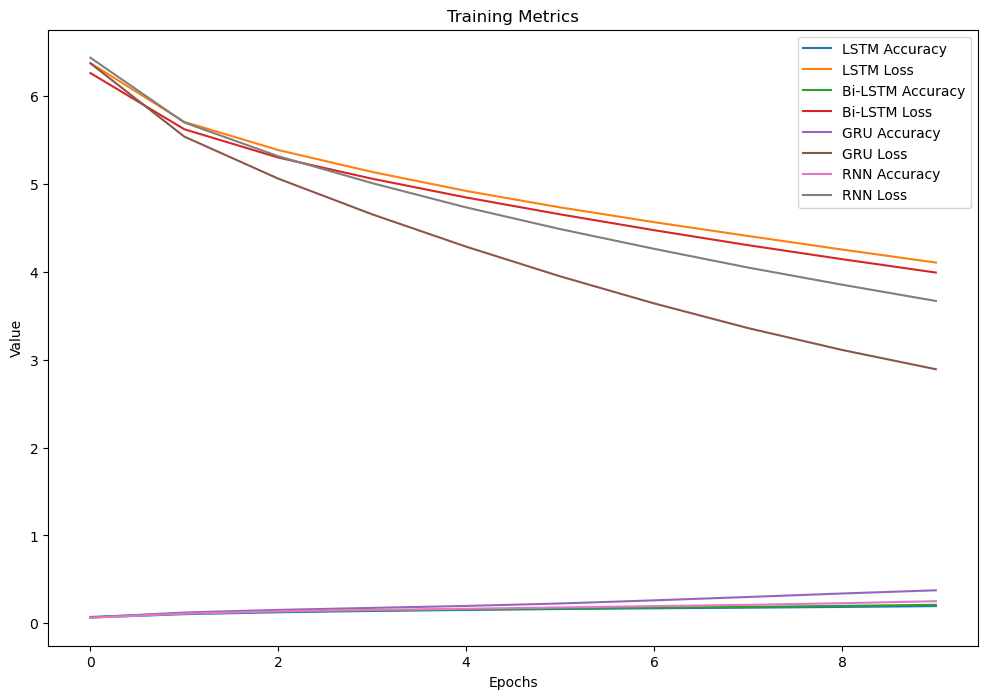

In [10]:
# Step 5: Plot training metrics
def plot_training_metrics(history_dict):
    plt.figure(figsize=(12, 8))
    for model_name, history in history_dict.items():
        plt.plot(history.history['accuracy'], label=f'{model_name} Accuracy')
        plt.plot(history.history['loss'], label=f'{model_name} Loss')
    plt.title('Training Metrics')
    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

plot_training_metrics(history_dict)



In [11]:
# Step 6: Next words prediction
def predict_next_words(model, tokenizer, input_text, num_words=5):
    input_text = input_text.lower()
    generated_words = []
    
    # Generate words iteratively
    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([input_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_length-1, padding='pre')
        predicted = model.predict(token_list, verbose=0)
        
        # Get the index of the predicted word
        predicted_word_index = np.argmax(predicted)
        
        # Find the word corresponding to the predicted index
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break
        
        # Append predicted word and update input_text for next prediction
        if output_word:
            generated_words.append(output_word)
            input_text += " " + output_word
        else:
            break
    
    return " ".join(generated_words)



In [12]:
def predict_gpt2(input_text, num_words):
    input_ids = gpt2_tokenizer.encode(input_text, return_tensors="pt")
    output = gpt2_model.generate(input_ids, max_length=len(input_ids[0]) + num_words, num_return_sequences=1)
    return gpt2_tokenizer.decode(output[0], skip_special_tokens=True)


In [13]:
# Flask App Setup
app = Flask(__name__)


In [14]:
@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    input_text = data.get("input_text", "")
    num_words = data.get("num_words", 5)  # Default to 5 words
    model_type = data.get("model_type", "lstm").lower()

    if not input_text:
        return jsonify({"error": "Input text is required."}), 400

    try:
        # Select the model based on the model_type
        if model_type == "lstm":
            model = tf.keras.models.load_model("LSTM_model.h5")
        elif model_type == "bi_lstm":
            model = tf.keras.models.load_model("Bi-LSTM_model.h5")
        elif model_type == "gru":
            model = tf.keras.models.load_model("GRU_model.h5")
        elif model_type == "rnn":
            model = tf.keras.models.load_model("RNN_model.h5")
        elif model_type == "gpt2":
            predicted_sequence = predict_gpt2(input_text, num_words)
            return jsonify({"input_text": input_text, "predicted_text": predicted_sequence})
        else:
            return jsonify({"error": "Invalid model type. Choose 'lstm', 'bi_lstm', 'gru', 'rnn', or 'gpt2'."}), 400

        # Predict the next words
        predicted_sequence = predict_next_words(model, tokenizer, input_text, num_words)
        return jsonify({"input_text": input_text, "predicted_text": predicted_sequence})
    except Exception as e:
        return jsonify({"error": str(e)}), 500


In [15]:
if __name__ == '__main__':
    app.run(debug=True)  # Use a different port



 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
